In [30]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [31]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [32]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cpu


In [33]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_data = np.load(
    PROCESSED_DIR / "train_sequences.npz"
)

val_data = np.load(
    PROCESSED_DIR / "val_sequences.npz"
)

test_data = np.load(
    PROCESSED_DIR / "test_sequences.npz"
)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (12407, 30, 15)
Validation: (2612, 30, 15)
Test: (2612, 30, 15)


In [34]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

### DataLoaders

In [35]:
BATCH_SIZE = 128

In [36]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

### Building GRU

In [37]:
class GRURegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, hidden = self.gru(x)

        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction.squeeze(1)

## creating model

In [38]:
input_size = X_train.shape[2]

model = GRURegressor(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
)

model = model.to(device)

print(model)

GRURegressor(
  (gru): GRU(15, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [39]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

## Training fucntion

In [40]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() * X_batch.size(0)
        )

    return total_loss / len(loader.dataset)

## validation fucntion

In [41]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    predictions = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions.extend(
                outputs.cpu().numpy()
            )

            targets.extend(
                y_batch.cpu().numpy()
            )

    avg_loss = total_loss / len(
        loader.dataset
    )

    return (
        avg_loss,
        np.array(predictions),
        np.array(targets)
    )

# training

In [42]:
EPOCHS = 30

history = {
    "train_loss": [],
    "val_loss": []
}

In [43]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, _, _ = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01/30 | Train Loss: 11090.2462 | Val Loss: 8608.0187
Epoch 02/30 | Train Loss: 8931.3102 | Val Loss: 6974.9069
Epoch 03/30 | Train Loss: 7395.1561 | Val Loss: 5665.7919
Epoch 04/30 | Train Loss: 6146.9148 | Val Loss: 4634.6372
Epoch 05/30 | Train Loss: 5150.0443 | Val Loss: 3799.3583
Epoch 06/30 | Train Loss: 4352.1029 | Val Loss: 3138.2728
Epoch 07/30 | Train Loss: 3710.1726 | Val Loss: 2618.6298
Epoch 08/30 | Train Loss: 3190.0318 | Val Loss: 2216.7775
Epoch 09/30 | Train Loss: 2769.9490 | Val Loss: 1864.4038
Epoch 10/30 | Train Loss: 2434.2923 | Val Loss: 1615.0171
Epoch 11/30 | Train Loss: 2164.0328 | Val Loss: 1407.5160
Epoch 12/30 | Train Loss: 1940.0126 | Val Loss: 1246.7929
Epoch 13/30 | Train Loss: 1755.2803 | Val Loss: 1111.6465
Epoch 14/30 | Train Loss: 1623.1590 | Val Loss: 1008.9934
Epoch 15/30 | Train Loss: 1507.9011 | Val Loss: 961.2294
Epoch 16/30 | Train Loss: 1386.0443 | Val Loss: 878.9188
Epoch 17/30 | Train Loss: 1306.2136 | Val Loss: 828.1206
Epoch 18/30 | Tr

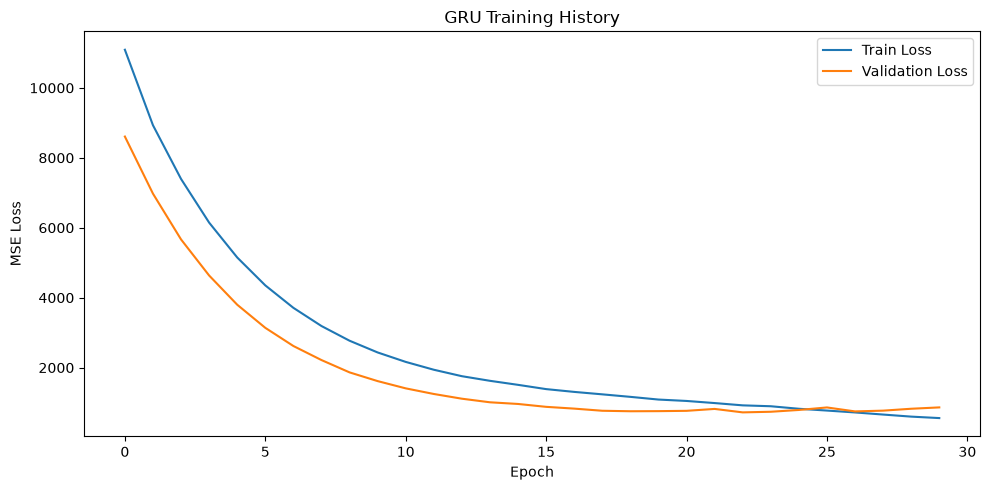

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training History")

plt.legend()
plt.tight_layout()
plt.show()

## Validation predictions 

In [45]:
val_loss, gru_val_predictions, gru_val_targets = validate(
    model,
    val_loader,
    criterion,
    device
)

In [46]:
gru_val_mae = mean_absolute_error(
    gru_val_targets,
    gru_val_predictions
)

gru_val_rmse = np.sqrt(
    mean_squared_error(
        gru_val_targets,
        gru_val_predictions
    )
)

print("GRU Validation MAE:", gru_val_mae)
print("GRU Validation RMSE:", gru_val_rmse)

GRU Validation MAE: 19.432668685913086
GRU Validation RMSE: 29.37411173025333


## Compare LSTM vs GRU

In [47]:
baseline_results = pd.read_csv(
    PROJECT_ROOT /
    "artifacts" /
    "baseline_results.csv"
)

In [48]:
gru_result = pd.DataFrame([
    {
        "Model": "GRU",
        "MAE": gru_val_mae,
        "RMSE": gru_val_rmse
    }
])

In [49]:
comparison = pd.concat(
    [
        baseline_results,
        gru_result
    ],
    ignore_index=True
)

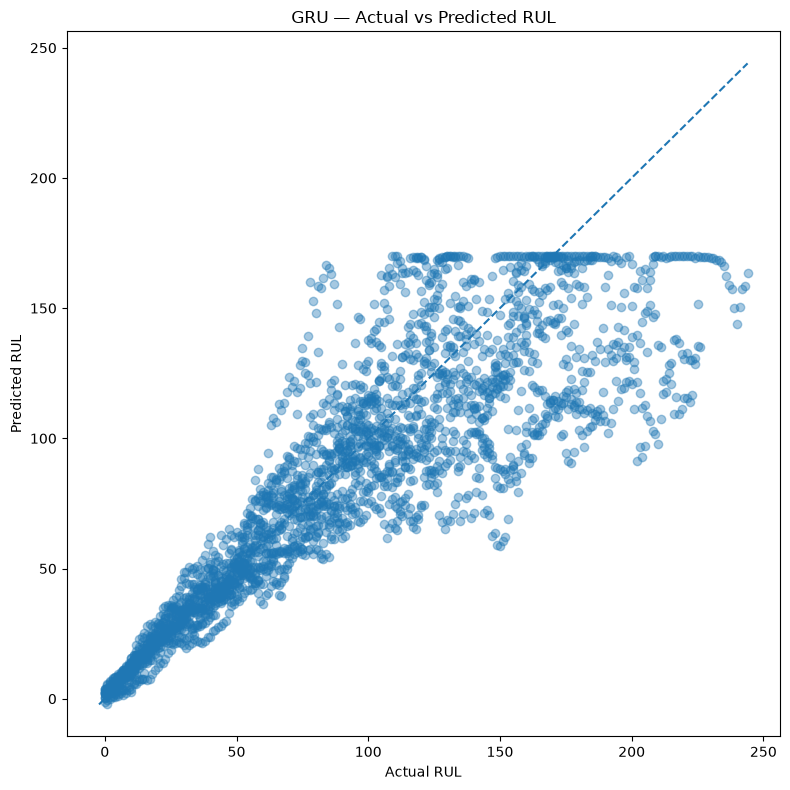

In [50]:
plt.figure(figsize=(8, 8))

plt.scatter(
    gru_val_targets,
    gru_val_predictions,
    alpha=0.4
)

min_value = min(
    gru_val_targets.min(),
    gru_val_predictions.min()
)

max_value = max(
    gru_val_targets.max(),
    gru_val_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("GRU — Actual vs Predicted RUL")

plt.tight_layout()
plt.show()

### infrence time measnurement

In [51]:
start = time.perf_counter()

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        _ = model(X_batch)

elapsed = time.perf_counter() - start

print(
    f"Total inference time: "
    f"{elapsed:.4f} seconds"
)

Total inference time: 0.5776 seconds


In [52]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [53]:
print(
    "GRU parameters:",
    count_parameters(model)
)

GRU parameters: 154881


In [54]:
MODEL_DIR = (
    PROJECT_ROOT /
    "artifacts" /
    "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": input_size,
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.2
    },
    MODEL_DIR / "gru_baseline.pt"
)